**Цель ноутбука:**
1. Сравнить модели классификации
2. Выбрать лучшую по ROC-AUC

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parent / 'src'))
from preprocessing import load_data, split_data, build_preprocessor
from modeling import train_and_evaluate

In [2]:
df = load_data()

X_train, X_test, y_train, y_test = split_data(df)

In [3]:
preprocessor = build_preprocessor()

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

In [4]:
rows = []

for model_name in ["logistic", "tree", "rf"]:
    model, metrics, _ = train_and_evaluate(
        X_train_proc,
        X_test_proc,
        y_train,
        y_test,
        model_name
    )

    rows.append({
        "model": model_name,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "roc_auc": metrics["roc_auc"]
    })

results = pd.DataFrame(rows)
results

,model,accuracy,precision,recall,roc_auc
0,logistic,0.735271,0.727124,0.753148,0.812204
1,tree,0.735766,0.714341,0.785684,0.812851
2,rf,0.742202,0.719318,0.794313,0.817623


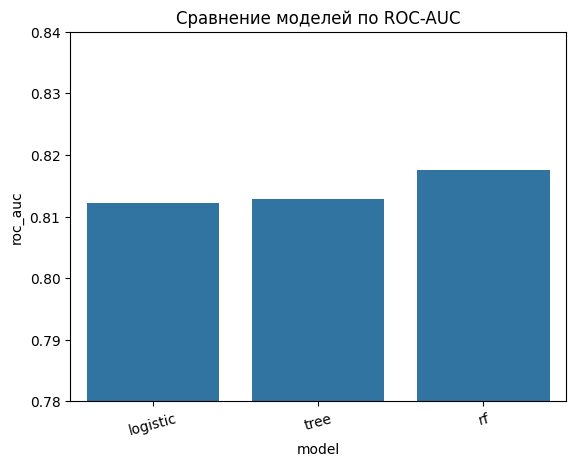

In [5]:
sns.barplot(data=results, x="model", y="roc_auc")
plt.title("Сравнение моделей по ROC-AUC")
plt.ylim(0.78, 0.84)
plt.xticks(rotation=15)
plt.show()

In [6]:
results.sort_values("roc_auc", ascending=False)

,model,accuracy,precision,recall,roc_auc
2,rf,0.742202,0.719318,0.794313,0.817623
1,tree,0.735766,0.714341,0.785684,0.812851
0,logistic,0.735271,0.727124,0.753148,0.812204


In [7]:
best = results.sort_values("roc_auc", ascending=False).iloc[0]
best

model              rf
accuracy     0.742202
precision    0.719318
recall       0.794313
roc_auc      0.817623
Name: 2, dtype: object

**Пояснение:**

Logistic Regression:
+ простая и интерпретируемая

Decision Tree:
+ понятная логика решений

Random Forest:
+ лучшая итоговая точность
+ устойчивость к шуму
+ лучший ROC-AUC

**Финальный вывод:**

1. Все модели показали близкий уровень качества.
2. Лучший результат достигнут Random Forest.
3. Для production-версии проекта выбрана Random Forest.